In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import os

In [2]:
curr_dir_path = os.getcwd()
main_dir_path = os.path.abspath(os.path.join(curr_dir_path, os.pardir))
data_dir_path = os.path.join(main_dir_path, 'data')
raw_data_dir_path = os.path.join(data_dir_path, 'raw_data')
processed_data_dir_path = os.path.join(data_dir_path, 'processed_data')
cw_dir_path = os.path.join(data_dir_path, 'cw')
emissions_data_dir_path = os.path.join(raw_data_dir_path, 'emissions_data')
iea_data_dir_path = os.path.join(raw_data_dir_path, 'IEA_climate_policy_data')

In [3]:
emissions_total_df = pd.read_csv(os.path.join(processed_data_dir_path, 'total_emissions_with_policies.csv'))
# emissions_total_df.to_clipboard(index=False)
emissions_change_df = pd.read_csv(os.path.join(processed_data_dir_path, 'emissions_change_with_policies.csv'))

In [4]:
emissions_total_df.head()

,iso3,year,policies_per_year,policies_last_3_years,policies_last_5_years,policy_lag_1,policy_lag_2,policy_lag_3,policy_lag_4,policy_lag_5,policy_lag_6,policy_lag_7,policy_lag_8,policy_lag_9,income_group,prev_year_emission,avg_emissions_prev_3_years,total_emissions
0,AFG,2001,0,0,0,0,0,0,0,0,0,0,0,0,Low income,25.390391,25.390391,23.723115
1,AFG,2002,0,0,0,0,0,0,0,0,0,0,0,0,Low income,23.723115,24.556753,26.383509
2,AFG,2003,0,0,0,0,0,0,0,0,0,0,0,0,Low income,26.383509,25.165672,27.071538
3,AFG,2004,0,0,0,0,0,0,0,0,0,0,0,0,Low income,27.071538,25.726054,27.128799
4,AFG,2005,0,0,0,0,0,0,0,0,0,0,0,0,Low income,27.128799,26.861282,27.530896


In [5]:
emissions_change_df.head()

,iso3,year,policies_per_year,policies_last_3_years,policies_last_5_years,policy_lag_1,policy_lag_2,policy_lag_3,policy_lag_4,policy_lag_5,policy_lag_6,policy_lag_7,policy_lag_8,policy_lag_9,income_group,avg_change_prev_3_years,avg_change_prev_5_years,prev_year_change,emissions_change
0,AFG,2002,0,0,0,0,0,0,0,0,0,0,0,0,Low income,-0.067921,-0.067921,-0.067921,0.106289
1,AFG,2003,0,0,0,0,0,0,0,0,0,0,0,0,Low income,0.019184,0.019184,0.106289,0.025744
2,AFG,2004,0,0,0,0,0,0,0,0,0,0,0,0,Low income,0.021371,0.021371,0.025744,0.002113
3,AFG,2005,0,0,0,0,0,0,0,0,0,0,0,0,Low income,0.044715,0.016556,0.002113,0.014713
4,AFG,2006,1,1,1,0,0,0,0,0,0,0,0,0,Low income,0.014190,0.016188,0.014713,0.009749


### **Step 0 – Define Objectives**

| Option | Goal | Target Variable |
|-------|------|-----------------|
| 1️⃣ Predict emissions | Predict the **total CO₂ emissions** in a future year | `total_emissions` |
| 2️⃣ Estimate effect of policies | Estimate the **impact of policies on the change in emissions** | `emissions_change = total_emissions - prev_year_emission` |



## Define Functions

In [6]:
def time_series_train_test_split(df, target, features, split_year=2018, income_subset=None):
    
    if income_subset:
        test = df[(df.income_group.isin(income_subset)) & (df['year'] > split_year)]
    else:
        test = df[df['year'] > split_year]
    
    train = df[df['year'] <= split_year]
    

    print(f"Train shape: {train.shape}")
    print(f"Test shape: {test.shape}")

    print(f'train / test split: {train.shape[0] / df.shape[0]} / {test.shape[0] / df.shape[0]}')

    X_train, y_train = train[features], train[target]
    X_test, y_test = test[features], test[target]

    return X_train, y_train, X_test, y_test


In [7]:

def simple_rf_regressor(X_train, y_train, X_test, y_test):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, preds))
    print("R²:", r2_score(y_test, preds))

    return model


In [8]:
def train_and_test_model(df, target, features, split_year=2017, income_subset=None):
    X_train, y_train, X_test, y_test = time_series_train_test_split(df, target, features, split_year, income_subset)
    model = simple_rf_regressor(X_train, y_train, X_test, y_test)
    importance = pd.Series(model.feature_importances_, index=features)
    print(importance.sort_values(ascending=False))
    importance.sort_values(ascending=False).plot(kind='barh')
    
    return model

## Train Models

### Prediction Model

Train shape: (3230, 18)
Test shape: (950, 18)
train / test split: 0.7727272727272727 / 0.22727272727272727
MAE: 19.017347733163778
R²: 0.9873936142711724
prev_year_emission            0.598438
avg_emissions_prev_3_years    0.392479
policy_lag_6                  0.001428
year                          0.001386
policy_lag_5                  0.001373
policy_lag_9                  0.000969
policy_lag_7                  0.000901
policies_last_5_years         0.000757
policies_last_3_years         0.000494
policies_per_year             0.000361
policy_lag_2                  0.000342
policy_lag_4                  0.000286
policy_lag_3                  0.000275
policy_lag_8                  0.000264
policy_lag_1                  0.000247
dtype: float64


RandomForestRegressor(random_state=42)

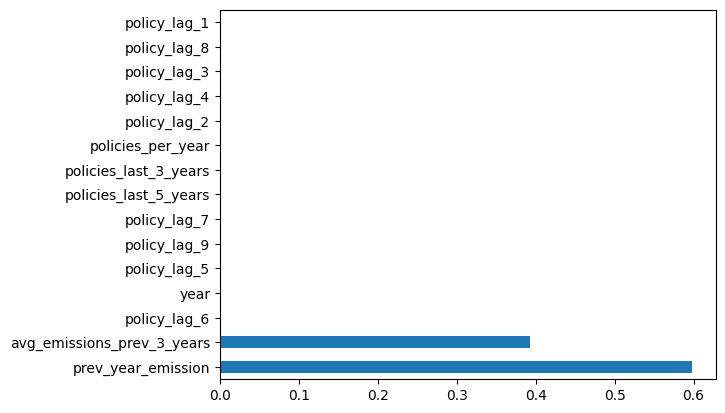

In [9]:
target = 'total_emissions'
features = emissions_total_df.drop(columns=['total_emissions', 'income_group', 'iso3']).columns
train_and_test_model(emissions_total_df, target, features)

In [10]:
emissions_total_df.income_group.unique()

array(['Low income', 'Lower middle income', 'Upper middle income',
       'High income'], dtype=object)

Train shape: (3230, 18)
Test shape: (125, 18)
train / test split: 0.7727272727272727 / 0.029904306220095694
MAE: 2.3479361440008635
R²: 0.9943934692446944
prev_year_emission            0.598438
avg_emissions_prev_3_years    0.392479
policy_lag_6                  0.001428
year                          0.001386
policy_lag_5                  0.001373
policy_lag_9                  0.000969
policy_lag_7                  0.000901
policies_last_5_years         0.000757
policies_last_3_years         0.000494
policies_per_year             0.000361
policy_lag_2                  0.000342
policy_lag_4                  0.000286
policy_lag_3                  0.000275
policy_lag_8                  0.000264
policy_lag_1                  0.000247
dtype: float64


RandomForestRegressor(random_state=42)

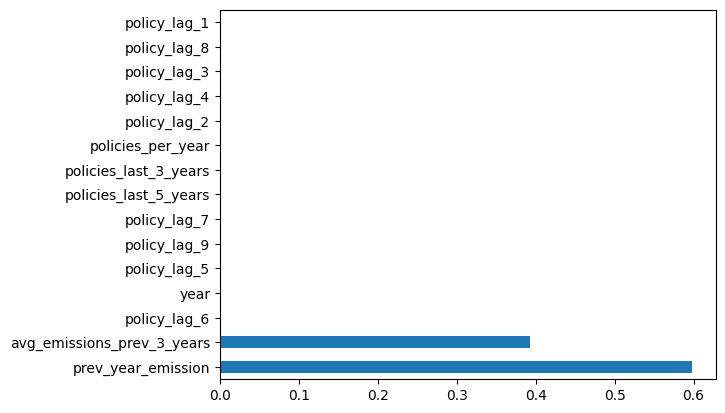

In [11]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Low income'])

Train shape: (3230, 18)
Test shape: (265, 18)
train / test split: 0.7727272727272727 / 0.06339712918660287
MAE: 12.750623601940289
R²: 0.9873538773855306
prev_year_emission            0.598438
avg_emissions_prev_3_years    0.392479
policy_lag_6                  0.001428
year                          0.001386
policy_lag_5                  0.001373
policy_lag_9                  0.000969
policy_lag_7                  0.000901
policies_last_5_years         0.000757
policies_last_3_years         0.000494
policies_per_year             0.000361
policy_lag_2                  0.000342
policy_lag_4                  0.000286
policy_lag_3                  0.000275
policy_lag_8                  0.000264
policy_lag_1                  0.000247
dtype: float64


RandomForestRegressor(random_state=42)

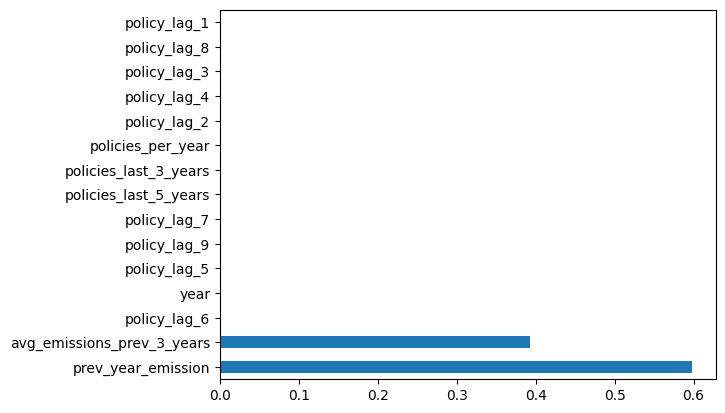

In [12]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Lower middle income'])


Train shape: (3230, 18)
Test shape: (240, 18)
train / test split: 0.7727272727272727 / 0.05741626794258373
MAE: 42.73760103410161
R²: 0.9861152337979241
prev_year_emission            0.598438
avg_emissions_prev_3_years    0.392479
policy_lag_6                  0.001428
year                          0.001386
policy_lag_5                  0.001373
policy_lag_9                  0.000969
policy_lag_7                  0.000901
policies_last_5_years         0.000757
policies_last_3_years         0.000494
policies_per_year             0.000361
policy_lag_2                  0.000342
policy_lag_4                  0.000286
policy_lag_3                  0.000275
policy_lag_8                  0.000264
policy_lag_1                  0.000247
dtype: float64


RandomForestRegressor(random_state=42)

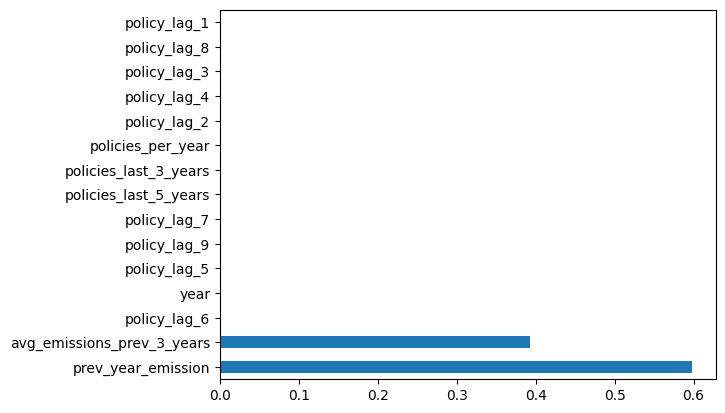

In [13]:
train_and_test_model(emissions_total_df, target, features, income_subset=['Upper middle income'])


Train shape: (3230, 18)
Test shape: (320, 18)
train / test split: 0.7727272727272727 / 0.07655502392344497
MAE: 12.928277580646618
R²: 0.9940189335297435
prev_year_emission            0.598438
avg_emissions_prev_3_years    0.392479
policy_lag_6                  0.001428
year                          0.001386
policy_lag_5                  0.001373
policy_lag_9                  0.000969
policy_lag_7                  0.000901
policies_last_5_years         0.000757
policies_last_3_years         0.000494
policies_per_year             0.000361
policy_lag_2                  0.000342
policy_lag_4                  0.000286
policy_lag_3                  0.000275
policy_lag_8                  0.000264
policy_lag_1                  0.000247
dtype: float64


RandomForestRegressor(random_state=42)

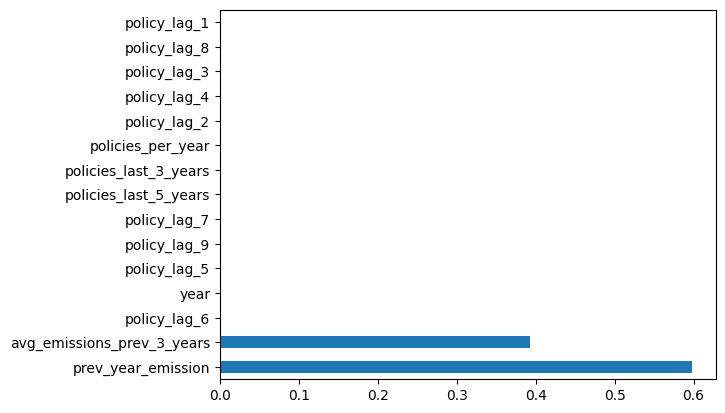

In [14]:
train_and_test_model(emissions_total_df, target, features, income_subset=['High income'])

### Estimate the effect of policies

Train shape: (2693, 19)
Test shape: (848, 19)
train / test split: 0.7605196272239481 / 0.23948037277605197
MAE: 0.0635184450469763
R²: -0.6729860839612156
avg_change_prev_5_years    0.304592
avg_change_prev_3_years    0.230606
prev_year_change           0.186257
year                       0.101610
policies_last_5_years      0.039615
policy_lag_8               0.031603
policies_last_3_years      0.018863
policy_lag_4               0.016913
policy_lag_5               0.013338
policy_lag_7               0.011612
policy_lag_2               0.008519
policy_lag_9               0.008477
policies_per_year          0.008289
policy_lag_3               0.007499
policy_lag_1               0.006700
policy_lag_6               0.005506
dtype: float64


RandomForestRegressor(random_state=42)

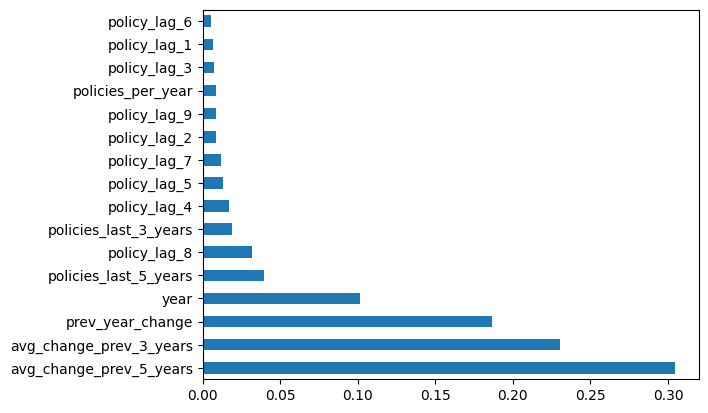

In [15]:
target = 'emissions_change'
features = emissions_change_df.drop(columns=['emissions_change', 'income_group', 'iso3']).columns

train_and_test_model(emissions_change_df, target, features)

Train shape: (2693, 19)
Test shape: (108, 19)
train / test split: 0.7605196272239481 / 0.030499858796950014


MAE: 0.07157038433469223
R²: -11.944028202109216
avg_change_prev_5_years    0.304592
avg_change_prev_3_years    0.230606
prev_year_change           0.186257
year                       0.101610
policies_last_5_years      0.039615
policy_lag_8               0.031603
policies_last_3_years      0.018863
policy_lag_4               0.016913
policy_lag_5               0.013338
policy_lag_7               0.011612
policy_lag_2               0.008519
policy_lag_9               0.008477
policies_per_year          0.008289
policy_lag_3               0.007499
policy_lag_1               0.006700
policy_lag_6               0.005506
dtype: float64


RandomForestRegressor(random_state=42)

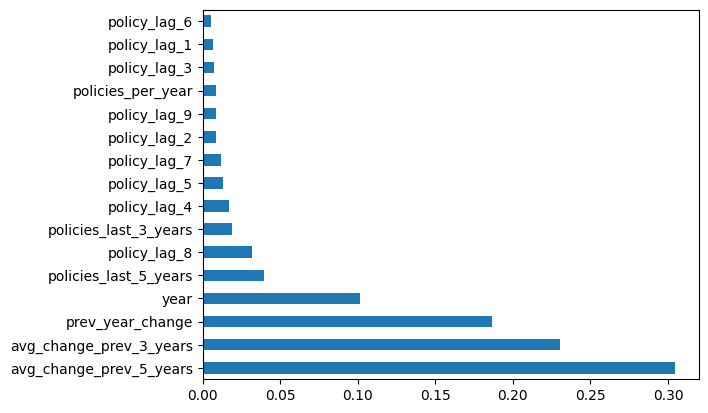

In [16]:
train_and_test_model(emissions_change_df, target, features, income_subset=['Low income'])


Train shape: (2693, 19)
Test shape: (215, 19)
train / test split: 0.7605196272239481 / 0.06071731149392827
MAE: 0.04254840812719307
R²: -0.43813301421480033
avg_change_prev_5_years    0.304592
avg_change_prev_3_years    0.230606
prev_year_change           0.186257
year                       0.101610
policies_last_5_years      0.039615
policy_lag_8               0.031603
policies_last_3_years      0.018863
policy_lag_4               0.016913
policy_lag_5               0.013338
policy_lag_7               0.011612
policy_lag_2               0.008519
policy_lag_9               0.008477
policies_per_year          0.008289
policy_lag_3               0.007499
policy_lag_1               0.006700
policy_lag_6               0.005506
dtype: float64


RandomForestRegressor(random_state=42)

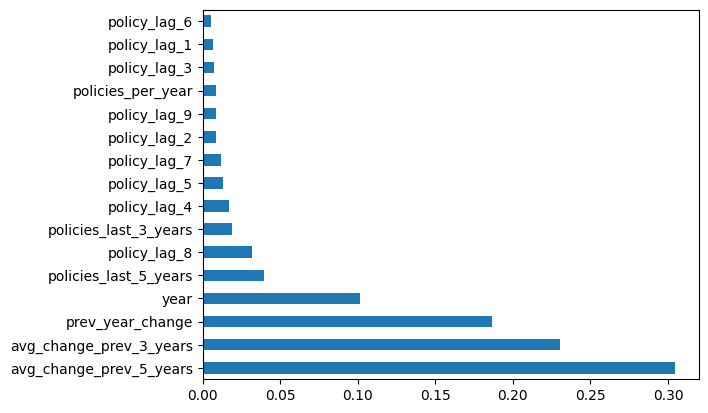

In [17]:
train_and_test_model(emissions_change_df, target, features, income_subset=['Lower middle income'])



Train shape: (2693, 19)
Test shape: (215, 19)
train / test split: 0.7605196272239481 / 0.06071731149392827
MAE: 0.07458879605046136
R²: -0.39486047810720093
avg_change_prev_5_years    0.304592
avg_change_prev_3_years    0.230606
prev_year_change           0.186257
year                       0.101610
policies_last_5_years      0.039615
policy_lag_8               0.031603
policies_last_3_years      0.018863
policy_lag_4               0.016913
policy_lag_5               0.013338
policy_lag_7               0.011612
policy_lag_2               0.008519
policy_lag_9               0.008477
policies_per_year          0.008289
policy_lag_3               0.007499
policy_lag_1               0.006700
policy_lag_6               0.005506
dtype: float64


RandomForestRegressor(random_state=42)

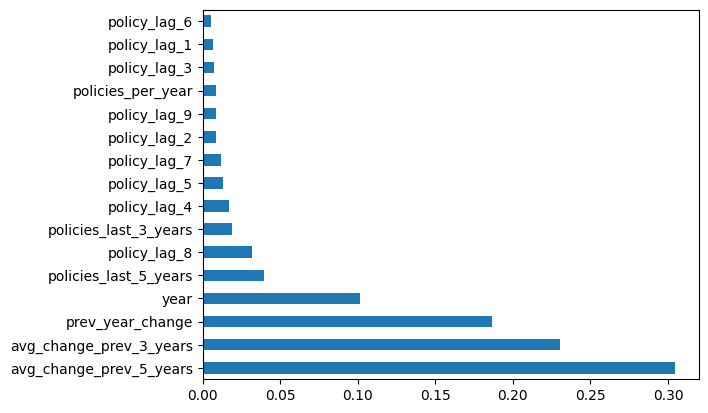

In [18]:
train_and_test_model(emissions_change_df, target, features, income_subset=['Upper middle income'])


Train shape: (2693, 19)
Test shape: (310, 19)
train / test split: 0.7605196272239481 / 0.0875458909912454
MAE: 0.06757916449514013
R²: 0.09774182084851524
avg_change_prev_5_years    0.304592
avg_change_prev_3_years    0.230606
prev_year_change           0.186257
year                       0.101610
policies_last_5_years      0.039615
policy_lag_8               0.031603
policies_last_3_years      0.018863
policy_lag_4               0.016913
policy_lag_5               0.013338
policy_lag_7               0.011612
policy_lag_2               0.008519
policy_lag_9               0.008477
policies_per_year          0.008289
policy_lag_3               0.007499
policy_lag_1               0.006700
policy_lag_6               0.005506
dtype: float64


RandomForestRegressor(random_state=42)

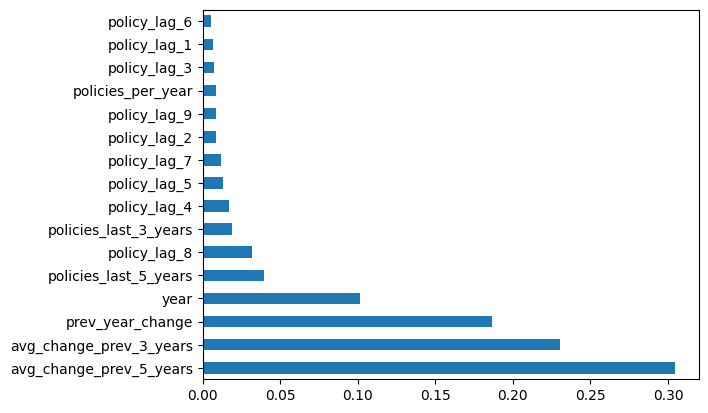

In [19]:
train_and_test_model(emissions_change_df, target, features, income_subset=['High income'])